  GPGN470/570: Remote Sensing, Homework 4 - Landsat
  M. Siegfried, siegfried@mines.edu
  
  Jupyter Notebook to get started with HW4
  

In [1]:
# Import the packages you'll need
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

In [4]:
######### HELPER FUNCTIONS
# Function for histogram equalization. Takes an image in, spits a stretched image out
def histeq(im,n_bins=256):
    
    #get image histogram
    vals,bins = np.histogram(im.flatten(), bins=n_bins, range=(0,n_bins), density=True)
    cdf = np.cumsum(vals)
    im2 = np.interp(im.flatten(),bins[:-1],cdf*255)
    im2[im2>255]=255
    return im2.reshape(im.shape)

# Function for linear contrast stretch. Takes an image in, spits a stretched image out
def histlin(im,n_bins=256):
    
    # find min and max of image
    pixels=im.flatten()
    minval=pixels.min()
    maxval=pixels.max()
    
    im2 = (pixels - minval)/(maxval-minval)*255
    return im2.reshape(im.shape)
#########

Problem 2

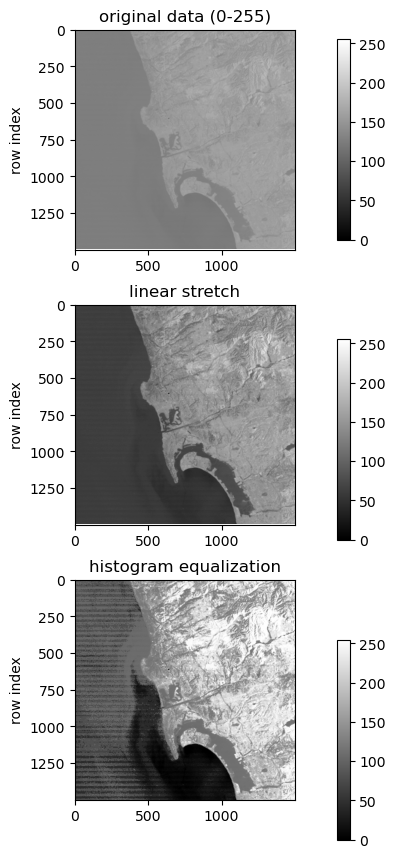

In [7]:
### Part 1: Plot the images with different contrast enhancement

# load thermal IR (band 6)
with open ('data/band6c.raw','rb') as fid:
    b6 = np.fromfile(fid,count=-1,dtype='uint8').reshape(1500,1500)

# Make a 3 panel figure with no contrast stretch, linear stretch, and hist equalization
# Plot all of them on 0 to 255 (8-bit) scale
fig, (ax1,ax2,ax3) = plt.subplots(3,1)
fig.set_figheight(10) # make the figure bigger
plt.subplots_adjust(hspace=0.25)

# Panel 1: No contrast stretch
ax1.set_title('original data (0-255)')
im1 = ax1.imshow(b6, cmap='gray', clim=(0,255))
ax1.set_ylabel('row index')
cax = plt.axes([0.75, 0.67, 0.02, 0.2]) # set colorbar position and size
cbar=plt.colorbar(im1, cax=cax) # plot the colorbar

# Panel 2: Linear contrast stretch
ax2.set_title('linear stretch')

# Apply linear contrast stretch
b6_linear = histlin(b6)

# Display
im2 = ax2.imshow(b6_linear, cmap='gray', clim=(0,255))
ax2.set_ylabel('row index')
cax2 = plt.axes([0.75, 0.37, 0.02, 0.2])  # adjust colorbar
plt.colorbar(im2, cax=cax2)


# Panel 3: Histogram equalization
ax3.set_title('histogram equalization')
# Apply histogram equalization
b6_histeq = histeq(b6)

# Display
im3 = ax3.imshow(b6_histeq, cmap='gray', clim=(0,255))
ax3.set_ylabel('row index')
cax3 = plt.axes([0.75, 0.07, 0.02, 0.2])  # adjust colorbar
plt.colorbar(im3, cax=cax3)


plt.show()


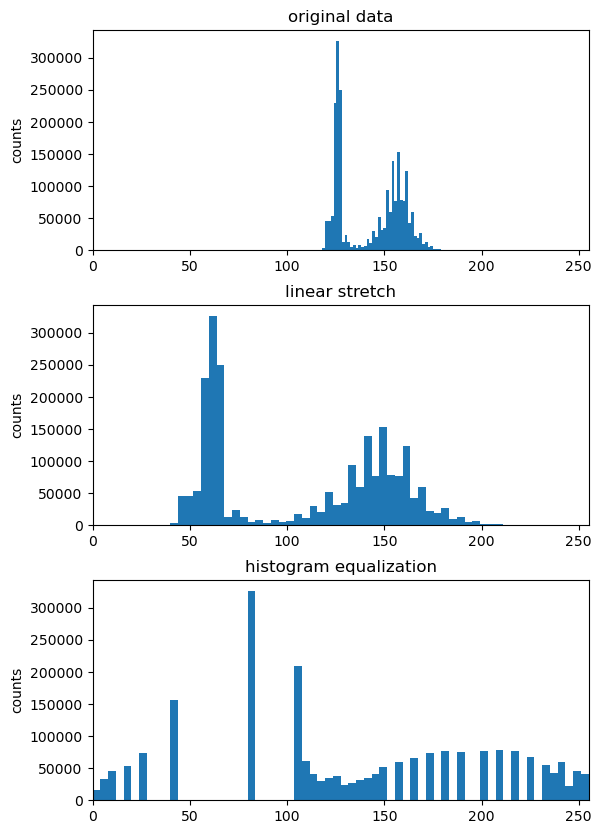

In [8]:
### Part 2: Look at all the histograms

# Make a 3 panel figure showing all the histograms
fig, (ax1,ax2,ax3) = plt.subplots(3,1)
fig.set_figheight(10) # make the figure bigger
plt.subplots_adjust(hspace=0.25)

# Panel 1: Histogram of original data
im1 = ax1.hist(b6.ravel(),bins=64)
ax1.set_xlim(0,255)
ax1.set_ylabel('counts')
ax1.set_title('original data')

# Panel 2: Histogram of data with linear stretch
ax2.set_xlim(0,255)
ax2.set_title('linear stretch')

ax2.hist(b6_linear.ravel(), bins=64)
ax2.set_xlim(0,255)
ax2.set_ylabel('counts')
ax2.set_title('linear stretch')

# Panel 3: Histogram of data with histogram equalization
ax3.set_xlim(0,255)
ax3.set_title('histogram equalization')

ax3.hist(b6_histeq.ravel(), bins=64)
ax3.set_xlim(0,255)
ax3.set_ylabel('counts')
ax3.set_title('histogram equalization')

plt.show()

Problem 3

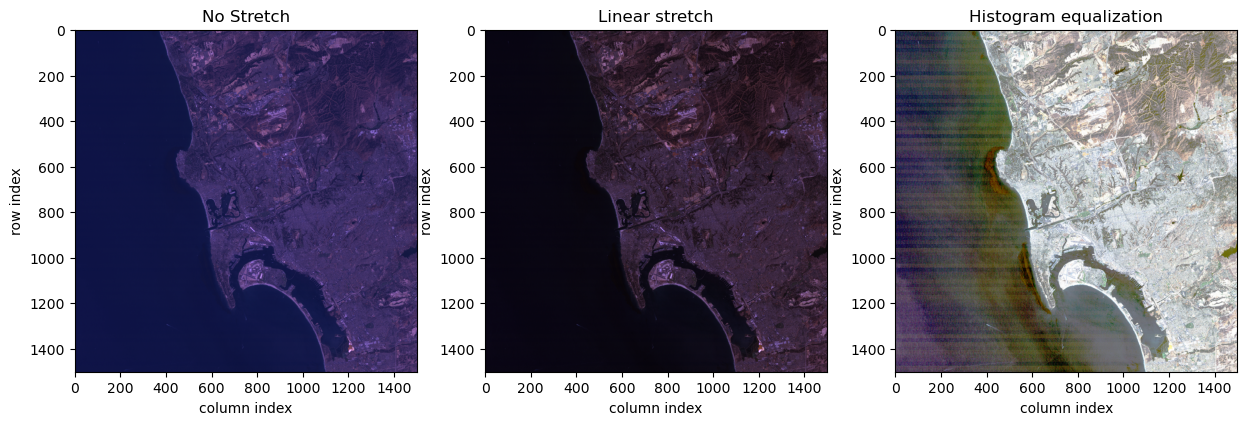

In [16]:
#
# Read in three bands for red, green, and blue
# Load all 7 bands into a list
bands = []
for i in range(1, 8):  # bands 1 to 7
    with open(f'data/band{i}c.raw', 'rb') as fid:
        band = np.fromfile(fid, count=-1, dtype='uint8').reshape(1500,1500)
        bands.append(band)

# Assign RGB bands
rr = bands[2]  # band3
gg = bands[1]  # band2
bb = bands[0]  # band1

# --- Linear contrast stretch ---
rr_line = histlin(rr)
gg_line = histlin(gg)
bb_line = histlin(bb)

# --- Histogram equalization ---
rr_eq = histeq(rr)
gg_eq = histeq(gg)
bb_eq = histeq(bb)

#
# stack the bands to create an MxNx3 matrix for display
# Do you think you apply contrast enhancement before or after you stack?
#
# Apply linear stretch to each band
rr_line = histlin(rr)
gg_line = histlin(gg)
bb_line = histlin(bb)

# Apply histogram equalization to each band
rr_eq = histeq(rr)
gg_eq = histeq(gg)
bb_eq = histeq(bb)

# Stack the stretched bands into an RGB image

rgb = np.stack((rr,gg,bb),axis=2) / 255.0
rgb_line = np.stack((rr_line, gg_line, bb_line), axis=2) / 255.0
rgb_eq = np.stack((rr_eq, gg_eq, bb_eq), axis=2) / 255.0

# plot the three images on a single three-panel figure
fig, (ax1,ax2,ax3) = plt.subplots(1,3)
fig.set_figwidth(15) # make the figure bigger

# Panel 1: regular old RGB with original data
ax1.imshow(rgb)
ax1.set_ylabel('row index')
ax1.set_xlabel('column index')
ax1.set_title('No Stretch')

# Panel 2: RGB image with linear stretch
# (hint: histlin spits out an image on a 0-255 scale, but imshow only lets you use 0-1)
ax2.imshow(rgb_line)
ax2.set_ylabel('row index')
ax2.set_xlabel('column index')
ax2.set_title('Linear stretch')

# Panel 3: RGB image with histogram equalization
# (hint: histeq spits out an image on a 0-255 scale, but imshow only lets you use 0-1)
ax3.imshow(rgb_eq)
ax3.set_ylabel('row index')
ax3.set_xlabel('column index')
ax3.set_title('Histogram equalization')

plt.show()

Problem 4

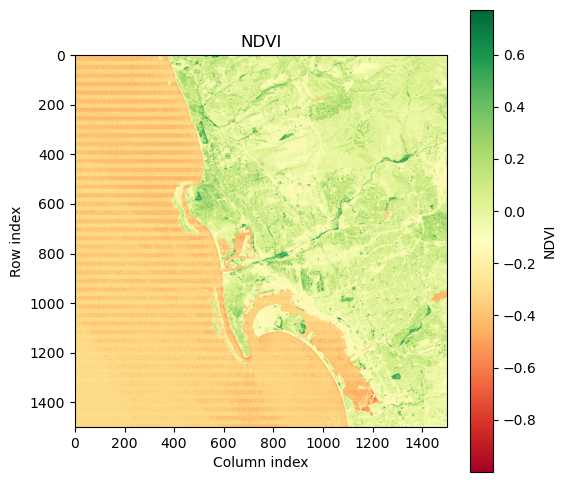

In [18]:
#
# Read in the appropriate bands and convert them to floats
#
with open ('data/band3c.raw','rb') as fid:
    rr = np.fromfile(fid,count=-1,dtype='uint8').reshape(1500,1500).astype(float)

with open ('data/band4c.raw','rb') as fid:
    ir = np.fromfile(fid,count=-1,dtype='uint8').reshape(1500,1500).astype(float)

#
# calculate the NDVI and display with imshow.
#
# Compute NDVI (add small epsilon to avoid division by zero)
ndvi = (ir - rr) / (ir + rr + 1e-6)

plt.figure(figsize=(6,6))
plt.imshow(ndvi, cmap='RdYlGn')  # green = high NDVI, red = low
plt.colorbar(label='NDVI')
plt.title('NDVI')
plt.xlabel('Column index')
plt.ylabel('Row index')
plt.show()

In [ ]:
# Observation:
# - NDVI clearly separates vegetation (high NDVI) from water (low NDVI). 
# - Ocean is near zero or negative, so it appears very different from thermal IR, which highlights temperature gradients.

Problem 5

Text(0.5, 0, 'column index')

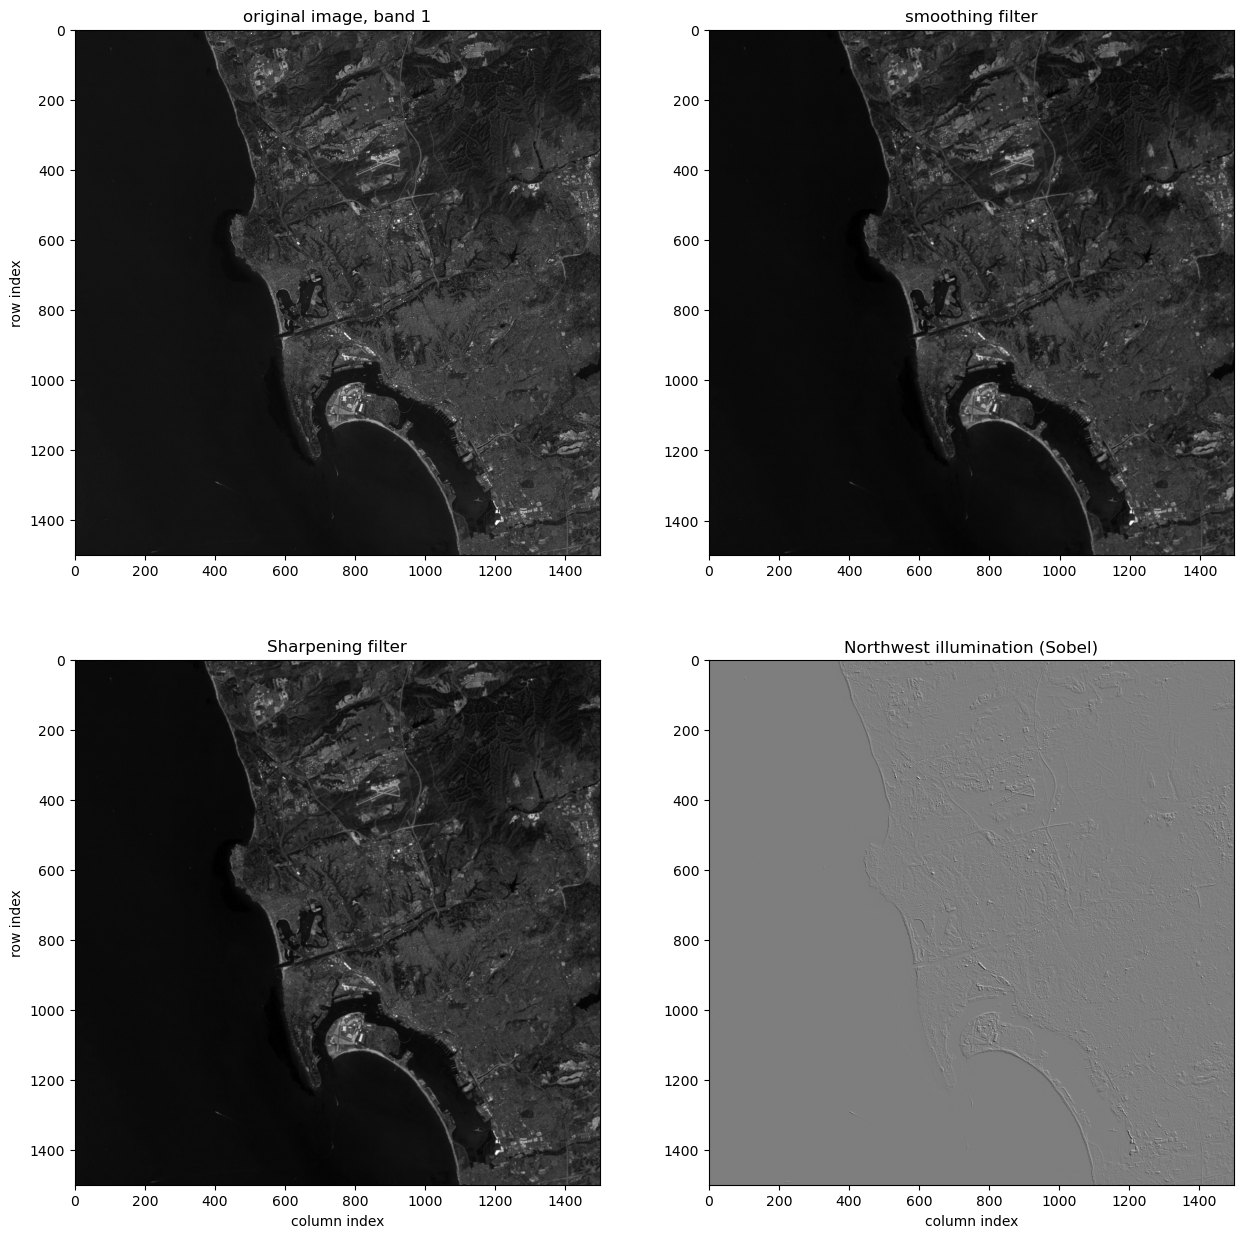

In [26]:
#
# Read band 1
#
with open ('data/band1c.raw','rb') as fid:
    bb = np.fromfile(fid,count=-1,dtype='uint8').reshape(1500,1500).astype(float)

# Make a four panel figure showing the original image, image with smoothing filter,
# image with sharpening filter, and image with Sobel illumination filter
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2, 2)
fig.set_figheight(15) # make the figure bigger
fig.set_figwidth(15)

# Panel 1: the original blue band, untouched
ax1.imshow(bb, cmap='gray')
ax1.set_title('original image, band 1')
ax1.set_ylabel('row index')

# Panel 2: apply a smoothing filter
# make a smoothing kernel (a 2D boxcar)
smoothfilt=np.array([[1/9, 1/9, 1/9],[1/9, 1/9, 1/9],[1/9, 1/9, 1/9]])
### this is a more flexible programmatic way of generating smoothing kernels
#wid=9
#smoothfilt=np.ones((wid,wid), dtype=float)*1/wid**2
###
# apply the kernel to the image as a 2d convolution with SciPy and show the result
ax2.imshow(scipy.signal.convolve2d(bb,smoothfilt, mode='valid'), cmap='gray')
ax2.set_title('smoothing filter')

# Panel 3: apply a sharpening filter
k = 0.1
bb_sharp = k*bb - (k-1)*bb_smooth

ax3.imshow(bb_sharp, cmap='gray')
ax3.set_title('Sharpening filter')
ax3.set_ylabel('row index')
ax3.set_xlabel('column index')

# Panel 4: illuminate the image from the northwest with a Sobel filter
# Sobel-like northwest kernel
sobel_nw = np.array([[ 0,  1,  2],
                     [-1,  0,  1],
                     [-2, -1,  0]])

bb_sobel = scipy.signal.convolve2d(bb, sobel_nw, mode='same', boundary='symm')

ax4.imshow(bb_sobel, cmap='gray')
ax4.set_title('Northwest illumination (Sobel)')
ax4.set_xlabel('column index')
